In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Book_review.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["rating"].value_counts().sort_index())

(12000, 4)
   Unnamed: 0  rating                                         reviewText  \
0           0       5  This book was the very first bookmobile book I...   
1           1       1  When I read the description for this book, I c...   
2           2       5  I just had to edit this review. This book is a...   
3           3       5  I don't normally buy 'mystery' novels because ...   
4           4       5  This isn't the kind of book I normally read, a...   

                           summary  
0                50 + years ago...  
1          Boring! Boring! Boring!  
2  Wiggleliscious/new toy ready/!!  
3                  Very good read.  
4                     Great Story!  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12000 non-null  int64 
 1   rating      12000 non-null  int64 
 2   reviewText  12000 non-null  object
 3

In [7]:
df = df[["rating", "reviewText", "summary"]].copy()

df["reviewText"] = df["reviewText"].astype(str)
df["summary"] = df["summary"].fillna("").astype(str)

df.head()

,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [9]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

print(df["sentiment"].value_counts())

sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


In [11]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_map)

df.head()

,rating,reviewText,summary,sentiment,label
0,5,This book was the very first bookmobile book I...,50 + years ago...,positive,2
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!,negative,0
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!,positive,2
3,5,I don't normally buy 'mystery' novels because ...,Very good read.,positive,2
4,5,"This isn't the kind of book I normally read, a...",Great Story!,positive,2


In [13]:
df["text"] = df["summary"] + " " + df["reviewText"]

df = df[["text", "sentiment", "label"]].copy()

df.head()

,text,sentiment,label
0,50 + years ago... This book was the very first...,positive,2
1,Boring! Boring! Boring! When I read the descri...,negative,0
2,Wiggleliscious/new toy ready/!! I just had to ...,positive,2
3,Very good read. I don't normally buy 'mystery'...,positive,2
4,Great Story! This isn't the kind of book I nor...,positive,2


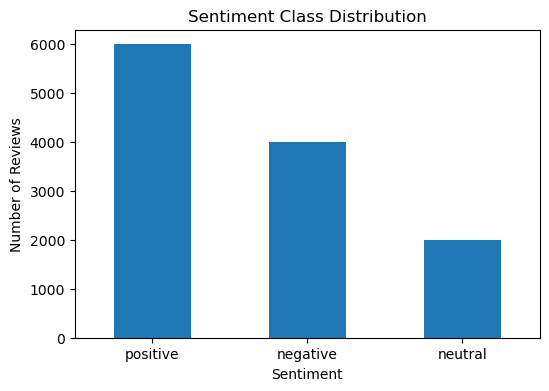

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [17]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "sentiment"]].head()

,text,clean_text,sentiment
0,50 + years ago... This book was the very first...,years ago this book was the very first bookmob...,positive
1,Boring! Boring! Boring! When I read the descri...,boring boring boring when i read the descripti...,negative
2,Wiggleliscious/new toy ready/!! I just had to ...,wigglelisciousnew toy ready i just had to edit...,positive
3,Very good read. I don't normally buy 'mystery'...,very good read i dont normally buy mystery nov...,positive
4,Great Story! This isn't the kind of book I nor...,great story this isnt the kind of book i norma...,positive


In [19]:
from sklearn.model_selection import train_test_split

X = df["clean_text"].values
y = df["label"].values

# 80% train+validation, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# From the 80%, take 15% as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 8160
Validation: 1440
Test: 2400


In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [27]:
lengths = [len(seq) for seq in X_train_seq]

MAX_LEN = int(np.percentile(lengths, 95))
print("95th percentile MAX_LEN:", MAX_LEN)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad:", X_train_pad.shape)
print("X_val_pad:", X_val_pad.shape)
print("X_test_pad:", X_test_pad.shape)

95th percentile MAX_LEN: 359
X_train_pad: (8160, 359)
X_val_pad: (1440, 359)
X_test_pad: (2400, 359)


In [29]:
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 3

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(y_train_cat.shape)
print(y_val_cat.shape)
print(y_test_cat.shape)

(8160, 3)
(1440, 3)
(2400, 3)


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 128

model_rnn = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    SimpleRNN(64),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model_rnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 359, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,707 (9.83 MB)

 Trainable params: 2,576,707 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.5136 - loss: 0.9915 - val_accuracy: 0.4889 - val_loss: 1.0250
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.5150 - loss: 0.9910 - val_accuracy: 0.4972 - val_loss: 1.0185
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.5202 - loss: 0.9773 - val_accuracy: 0.4917 - val_loss: 1.0348
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.5233 - loss: 0.9670 - val_accuracy: 0.4917 - val_loss: 1.0392
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.5240 - loss: 0.9643 - val_accuracy: 0.4924 - val_loss: 1.0560


In [44]:
rnn_test_loss, rnn_test_acc = model_rnn.evaluate(X_test_pad, y_test_cat)

print("Simple RNN Test Loss:", rnn_test_loss)
print("Simple RNN Test Accuracy:", rnn_test_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.4950 - loss: 1.0123
Simple RNN Test Loss: 1.0123474597930908
Simple RNN Test Accuracy: 0.4950000047683716


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 128

model_lstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(64),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 359, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,763 (9.97 MB)

 Trainable params: 2,613,763 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 141ms/step - accuracy: 0.4942 - loss: 1.0236 - val_accuracy: 0.5000 - val_loss: 1.0132
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.5002 - loss: 1.0175 - val_accuracy: 0.5000 - val_loss: 1.0125
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.5021 - loss: 1.0100 - val_accuracy: 0.5000 - val_loss: 1.0136
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.5105 - loss: 0.9940 - val_accuracy: 0.4993 - val_loss: 1.0247
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.5218 - loss: 0.9704 - val_accuracy: 0.4951 - val_loss: 1.0630


In [50]:
lstm_test_loss, lstm_test_acc = model_lstm.evaluate(X_test_pad, y_test_cat)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5000 - loss: 1.0123
LSTM Test Loss: 1.0123162269592285
LSTM Test Accuracy: 0.5


In [52]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_lstm_probs = model_lstm.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

target_names = ["negative", "neutral", "positive"]

print("Classification Report - LSTM")
print(classification_report(y_true, y_pred_lstm, target_names=target_names))

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step
Classification Report - LSTM
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       800
     neutral       0.00      0.00      0.00       400
    positive       0.50      1.00      0.67      1200

    accuracy                           0.50      2400
   macro avg       0.17      0.33      0.22      2400
weighted avg       0.25      0.50      0.33      2400



C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: class_weights_array[i]
    for i in range(len(class_weights_array))
}

print(class_weights)

{0: 1.0, 1: 2.0, 2: 0.6666666666666666}


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 128

model_lstm_fixed = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    Bidirectional(LSTM(64)),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model_lstm_fixed.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm_fixed.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 359, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,267 (10.17 MB)

 Trainable params: 2,667,267 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm_fixed = model_lstm_fixed.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 59s 207ms/step - accuracy: 0.6431 - loss: 0.8579 - val_accuracy: 0.7063 - val_loss: 0.6971
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 57s 224ms/step - accuracy: 0.8124 - loss: 0.5366 - val_accuracy: 0.7500 - val_loss: 0.6080
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 52s 205ms/step - accuracy: 0.9031 - loss: 0.3105 - val_accuracy: 0.7451 - val_loss: 0.7765
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 54s 212ms/step - accuracy: 0.9520 - loss: 0.1576 - val_accuracy: 0.7090 - val_loss: 0.8373
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 58s 225ms/step - accuracy: 0.9757 - loss: 0.0833 - val_accuracy: 0.7021 - val_loss: 1.1209


In [61]:
lstm_fixed_test_loss, lstm_fixed_test_acc = model_lstm_fixed.evaluate(X_test_pad, y_test_cat)

print("Fixed LSTM Test Loss:", lstm_fixed_test_loss)
print("Fixed LSTM Test Accuracy:", lstm_fixed_test_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7583 - loss: 0.5851
Fixed LSTM Test Loss: 0.5850575566291809
Fixed LSTM Test Accuracy: 0.7583333253860474


In [63]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_lstm_fixed_probs = model_lstm_fixed.predict(X_test_pad)
y_pred_lstm_fixed = np.argmax(y_pred_lstm_fixed_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

target_names = ["negative", "neutral", "positive"]

print("Classification Report - Fixed LSTM")
print(classification_report(
    y_true,
    y_pred_lstm_fixed,
    target_names=target_names,
    zero_division=0
))

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step
Classification Report - Fixed LSTM
              precision    recall  f1-score   support

    negative       0.83      0.77      0.80       800
     neutral       0.41      0.52      0.46       400
    positive       0.86      0.83      0.85      1200

    accuracy                           0.76      2400
   macro avg       0.70      0.71      0.70      2400
weighted avg       0.78      0.76      0.77      2400



In [66]:
!pip install gensim

In [68]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [70]:
word_index = tokenizer.word_index

EMBEDDING_DIM_GLOVE = 50
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM_GLOVE))

found_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_words += 1

print("Vocabulary size:", vocab_size)
print("Words found in GloVe:", found_words)
print("Coverage:", found_words / vocab_size)

Vocabulary size: 20000
Words found in GloVe: 16134
Coverage: 0.8067


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

model_glove_lstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM_GLOVE,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(LSTM(64)),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model_glove_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_glove_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 359, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,067,331 (4.07 MB)

 Trainable params: 67,331 (263.01 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [74]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_lstm = model_glove_lstm.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 52s 179ms/step - accuracy: 0.5539 - loss: 0.9849 - val_accuracy: 0.6632 - val_loss: 0.8178
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - accuracy: 0.6418 - loss: 0.8830 - val_accuracy: 0.6236 - val_loss: 0.8365
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 165ms/step - accuracy: 0.6723 - loss: 0.8346 - val_accuracy: 0.6826 - val_loss: 0.7613
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.6779 - loss: 0.7926 - val_accuracy: 0.6771 - val_loss: 0.7498
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.6990 - loss: 0.7571 - val_accuracy: 0.6951 - val_loss: 0.7178
Epoch 6/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.7061 - loss: 0.7371 - val_accuracy: 0.6868 - val_loss: 0.7242
Epoch 7/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 37s 146ms/step - accuracy: 0.7259 - loss: 0.7023 - val_accuracy: 0.6701 - val_loss: 0.7365
Epoch 8/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.7374 - loss: 0

In [77]:
glove_lstm_test_loss, glove_lstm_test_acc = model_glove_lstm.evaluate(X_test_pad, y_test_cat)

print("GloVe LSTM Test Loss:", glove_lstm_test_loss)
print("GloVe LSTM Test Accuracy:", glove_lstm_test_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.7000 - loss: 0.7073
GloVe LSTM Test Loss: 0.7072617411613464
GloVe LSTM Test Accuracy: 0.699999988079071


In [79]:
y_pred_glove_probs = model_glove_lstm.predict(X_test_pad)
y_pred_glove = np.argmax(y_pred_glove_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("Classification Report - GloVe LSTM")
print(classification_report(
    y_true,
    y_pred_glove,
    target_names=target_names,
    zero_division=0
))

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step
Classification Report - GloVe LSTM
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75       800
     neutral       0.32      0.40      0.35       400
    positive       0.84      0.77      0.80      1200

    accuracy                           0.70      2400
   macro avg       0.64      0.64      0.64      2400
weighted avg       0.72      0.70      0.71      2400



In [83]:
nlp_results = pd.DataFrame([
    ["Simple RNN", "Trainable Embedding", rnn_test_loss, rnn_test_acc],
    ["BiLSTM", "Trainable Embedding + Class Weights", lstm_fixed_test_loss, lstm_fixed_test_acc],
    ["GloVe BiLSTM", "Pretrained GloVe Embedding", glove_lstm_test_loss, glove_lstm_test_acc],
], columns=["Model", "Embedding Type", "Test Loss", "Test Accuracy"])

nlp_results["Test Accuracy (%)"] = nlp_results["Test Accuracy"] * 100
nlp_results

,Model,Embedding Type,Test Loss,Test Accuracy,Test Accuracy (%)
0,Simple RNN,Trainable Embedding,1.012347,0.495000,49.500000
1,BiLSTM,Trainable Embedding + Class Weights,0.585058,0.758333,75.833333
2,GloVe BiLSTM,Pretrained GloVe Embedding,0.707262,0.700000,69.999999


In [87]:
nlp_results.to_csv("nlp_model_results.csv", index=False)